In [ ]:
import colorsys
import pathlib
import tempfile
import urllib.request

In [ ]:
import marimo as mo
from matplotlib.colors import SymLogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
import pandas as pd
from teeplot import teeplot as tp
from watermark import watermark

In [ ]:
mo.md(
    f"""
```Text
{watermark(
    current_date=True,
    iso8601=True,
    machine=True,
    updated=True,
    python=True,
    iversions=True,
    globals_=globals(),
)}
```
"""
)

```Text
Last updated: 2026-08-03T15:56:27.456329+00:00

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1062-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

teeplot   : 1.4.2
matplotlib: 3.9.2
pandas    : 2.2.3
marimo    : 0.23.2

```

# Edge sparsity L1 x L2 grid (2026-08-01): loss vs. regularization strength

Downloads the collated timeseries parquet file for the
`2026-08-01-edge-sparsity-grid` SLURM batch job (see
`slurm/2026-08-01/2026-08-01-edge-sparsity-grid.sh`) from OSF, then
renders three 5-panel heatmap grids -- one panel per swept
`n_zero_edges` value (`0, 100, 125, 150, 175`, chosen to straddle the
sparsity-driven phenotype-composition collapse observed around
`n_zero_edges` ~95-110 in
`bindle/2026-07-31-exploratory-edge-sparsity-analysis.py`) -- each
panel a `l1_scale` (x, log) x `l2_scale` (y, log) heatmap, median
across the 3 replicate seeds:

1. Final testing chi^2 error.
2. Final training (actual) chi^2 error.
3. Final "classified" fraction (`1 - other_frac`, i.e. the share of
   the population landing on any of the 8 canonical `CLASS_8`
   phenotypes rather than "other") -- this is the metric that most
   directly showed the sparsity collapse in ad-hoc exploration of
   this dataset (and of `osf.io/6vrxc`/`osf.io/ykp74`, similar
   independent-L1/L2 grids not yet backed by a committed slurm
   script), so it's included here as its own panel rather than only
   inferred from the chi^2 plots.
4. Final phenotype composition (stacked fraction of each of the 8
   canonical `CLASS_8` phenotypes, plus "other") vs. `n_zero_edges`,
   as a facet grid -- one small stackplot panel per (`l1_scale`,
   `l2_scale`) grid cell (63 panels: 9 `l1_scale` columns x 7
   `l2_scale` rows) -- rather than the single-`n_zero_edges`-axis
   layout used for plots 1-3, since here both regularization axes
   are swept independently with no natural "off" baseline to
   collapse into a 2x2-style condition grid.
5. Final testing chi^2 error vs. `n_zero_edges`, same 63-panel facet
   layout as plot 4 -- median line with a shaded [min, max] band
   across the 3 replicate seeds per panel, instead of a stacked
   composition.
6. Final training (actual) chi^2 error vs. `n_zero_edges`, same
   layout as plot 5.

Unlike this project's other edge-sparsity analysis notebooks, L1 and
L2 here are swept INDEPENDENTLY (`l1_scale` in 9 values from 0.0001
to 1.0, `l2_scale` in 7 values from 0.00001 to 0.01, both in
half-decade steps -- NOT constrained to `l1_scale + l2_scale = 1`
like every other sweep in this project) -- so a heatmap over the
(l1_scale, l2_scale) plane is the natural layout, rather than the
line/stackplot-vs-n_zero_edges or 2x2-condition-panel layouts used
elsewhere. `n_classes=3` and `doubled_class=-1` (uniform
presentation) are both fixed for the whole dataset.

## Fetch data

In [ ]:
# https://osf.io/z3jbe -- 2026-08-01-edge-sparsity-grid collated
#   timeseries (l1_scale x l2_scale independently swept; n_classes=3,
#   doubled_class=-1 fixed; n_zero_edges in {0, 100, 125, 150, 175})
OSF_SLUGS = {
    "edge-sparsity-grid": "z3jbe",
}

In [ ]:
def fetch_osf(slug: str) -> "pathlib.Path":
    """Download a file from OSF by its slug, caching it under the system
    temp directory, and return the path to the cached file.

    Tries a plain stdlib download first; if that fails for any reason
    (auth wall, transient network error, redirect handling, ...) falls
    back to the `osf_fetch` utility from this project's `pylib` (ported
    from the same-named utility added to
    github.com/mmore500/paperproject.git), which is more robust
    (session handling via `requests`, on-disk caching)."""
    cache_path = pathlib.Path(tempfile.gettempdir()) / slug
    url = f"https://osf.io/{slug}/download"
    try:
        if not cache_path.exists():
            print(f"downloading {url} -> {cache_path}")
            request = urllib.request.Request(
                url, headers={"User-Agent": "evodd-bindle/1.0"}
            )
            with urllib.request.urlopen(request, timeout=180) as resp:
                cache_path.write_bytes(resp.read())
        else:
            print(f"reusing cached {cache_path}")
    except Exception as e:
        print(
            f"direct download of {url} failed ({e!r}), falling back to pylib.osf_fetch"
        )
        from pylib import osf_fetch

        cache_path = osf_fetch(slug)
    print(f"size: {cache_path.stat().st_size} bytes")
    return cache_path

In [ ]:
osf_paths = {name: fetch_osf(slug) for name, slug in OSF_SLUGS.items()}

downloading https://osf.io/z3jbe/download -> /tmp/z3jbe
direct download of https://osf.io/z3jbe/download failed (<HTTPError 308: 'Permanent Redirect'>), falling back to pylib.osf_fetch
downloading https://osf.io/z3jbe/download -> /tmp/z3jbe
size: 22662802 bytes
size: 22662802 bytes


## Load data

In [ ]:
df = pd.concat(
    [
        pd.read_parquet(path).assign(dataset=name)
        for name, path in osf_paths.items()
    ],
    ignore_index=True,
)
df["dataset"] = pd.Categorical(df["dataset"])

In [ ]:
pd.concat([df.head(), df.tail()])

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,test1_frac,test2_frac,test3_frac,test4_frac,test5_frac,...,n_zero_edges,n_classes,doubled_class,seed,l1_scale,l2_scale,num_epoch,train_class_idx,replicate_uid,dataset
0,0,0,61.066624,0.998003,0.998008,0.0000,0.0000,0.0000,0.0000,0.0000,...,0,3,-1,1,0.0001,0.00001,138889,"0,3,6",7aaff5b6-dfee-437f-94e3-f4019bf8e7e6,edge-sparsity-grid
1,1,138889,61.218588,0.998003,0.998008,0.0000,0.0000,0.0000,0.0000,0.0000,...,0,3,-1,1,0.0001,0.00001,138889,"0,3,6",7aaff5b6-dfee-437f-94e3-f4019bf8e7e6,edge-sparsity-grid
2,2,277778,61.238529,0.999001,0.999002,0.0000,0.0000,0.0000,0.0000,0.0000,...,0,3,-1,1,0.0001,0.00001,138889,"0,3,6",7aaff5b6-dfee-437f-94e3-f4019bf8e7e6,edge-sparsity-grid
3,3,416667,61.266456,0.998003,0.998008,0.0000,0.0000,0.0000,0.0000,0.0000,...,0,3,-1,1,0.0001,0.00001,138889,"0,3,6",7aaff5b6-dfee-437f-94e3-f4019bf8e7e6,edge-sparsity-grid
4,4,555556,61.294349,0.997004,0.997010,0.0005,0.0000,0.0000,0.0000,0.0000,...,0,3,-1,1,0.0001,0.00001,138889,"0,3,6",7aaff5b6-dfee-437f-94e3-f4019bf8e7e6,edge-sparsity-grid
165370,170,479583717,4986.063225,0.017533,1.044308,0.2850,0.0325,0.0335,0.2895,0.0345,...,0,3,-1,1,0.0001,0.00030,138889,"0,3,6",278d1cff-8eb3-4ecd-bafa-1deaed455a8c,edge-sparsity-grid
165371,171,479722606,4986.095007,0.017665,1.043848,0.2935,0.0325,0.0340,0.2850,0.0355,...,0,3,-1,1,0.0001,0.00030,138889,"0,3,6",278d1cff-8eb3-4ecd-bafa-1deaed455a8c,edge-sparsity-grid
165372,172,489861503,5107.111415,0.017212,1.051562,0.2925,0.0315,0.0340,0.2935,0.0355,...,0,3,-1,1,0.0001,0.00030,138889,"0,3,6",278d1cff-8eb3-4ecd-bafa-1deaed455a8c,edge-sparsity-grid
165373,173,490000392,5107.132180,0.017745,1.040100,0.2875,0.0330,0.0340,0.2870,0.0350,...,0,3,-1,1,0.0001,0.00030,138889,"0,3,6",278d1cff-8eb3-4ecd-bafa-1deaed455a8c,edge-sparsity-grid
165374,174,500000400,5168.967822,0.017294,1.047600,0.2900,0.0315,0.0345,0.2895,0.0340,...,0,3,-1,1,0.0001,0.00030,138889,"0,3,6",278d1cff-8eb3-4ecd-bafa-1deaed455a8c,edge-sparsity-grid


In [ ]:
df.describe()

,epoch,generation,walltime_sec,pure_train_chi2,test_chi2,test1_frac,test2_frac,test3_frac,test4_frac,test5_frac,...,l2_loss,regularization_loss,density,n_zero_edges,n_classes,doubled_class,seed,l1_scale,l2_scale,num_epoch
count,165375.000000,1.653750e+05,165375.000000,165375.000000,165375.000000,165375.000000,165375.000000,165375.000000,165375.000000,165375.000000,...,165375.000000,165375.000000,165375.000000,165375.000000,165375.0,165375.0,165375.000000,165375.000000,165375.000000,165375.0
mean,87.000000,1.711343e+08,1666.523059,0.506166,1.207850,0.080848,0.022568,0.027047,0.248526,0.023144,...,0.132807,0.007321,0.570312,110.000000,3.0,-1.0,2.000000,0.160489,0.002063,138889.0
std,50.517476,1.568387e+08,1520.050069,0.319289,0.906357,0.102849,0.033924,0.035470,0.189421,0.034360,...,0.155006,0.009386,0.235998,60.415413,0.0,0.0,0.816499,0.310771,0.003387,0.0
min,0.000000,0.000000e+00,61.025313,0.014339,0.000324,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.316406,0.000000,3.0,-1.0,1.000000,0.000100,0.000010,138889.0
25%,43.000000,2.041668e+07,184.120393,0.318885,0.769983,0.000500,0.000000,0.000000,0.105000,0.000000,...,0.018503,0.000497,0.414062,100.000000,3.0,-1.0,1.000000,0.001000,0.000030,138889.0
50%,87.000000,1.313890e+08,1279.641408,0.423219,0.996008,0.025000,0.004500,0.010000,0.248500,0.003500,...,0.083028,0.002744,0.511719,125.000000,3.0,-1.0,2.000000,0.010000,0.000300,138889.0
75%,131.000000,3.029169e+08,2921.507366,0.724573,1.438139,0.129500,0.033000,0.040500,0.389250,0.035000,...,0.184842,0.010546,0.609375,150.000000,3.0,-1.0,3.000000,0.100000,0.003000,138889.0
max,174.000000,5.000004e+08,6885.523855,1.952432,6.833152,0.478000,0.131000,0.218500,0.988000,0.134500,...,0.847067,0.050123,1.000000,175.000000,3.0,-1.0,3.000000,1.000000,0.010000,138889.0


## Verify the fixed condition, prepare the L1 x L2 grid

`n_classes` and `doubled_class` should each be a single fixed value
throughout this dataset, matching
`slurm/2026-08-01/2026-08-01-edge-sparsity-grid.sh`; `n_zero_edges`,
`l1_scale`, and `l2_scale` are the 3 swept axes.

In [ ]:
assert df["n_classes"].nunique() == 1 and df["n_classes"].iloc[0] == 3
assert (
    df["doubled_class"].nunique() == 1
    and df["doubled_class"].iloc[0] == -1
)
n_zero_values = sorted(df["n_zero_edges"].unique())
l1_values = sorted(df["l1_scale"].unique())
l2_values = sorted(df["l2_scale"].unique())

In [ ]:
condition_summary_df = pd.DataFrame(
    [
        {
            "n_classes": df["n_classes"].iloc[0],
            "doubled_class": df["doubled_class"].iloc[0],
            "n_zero_edges_values": str(n_zero_values),
            "n_l1_values": len(l1_values),
            "n_l2_values": len(l2_values),
            "n_seeds": df["seed"].nunique(),
            "n_replicates": df["replicate_uid"].nunique(),
        }
    ]
)
condition_summary_df

,n_classes,doubled_class,n_zero_edges_values,n_l1_values,n_l2_values,n_seeds,n_replicates
0,3,-1,"[np.int64(0), np.int64(100), np.int64(125), np.int64(150), np.int64(175)]",9,7,3,945


## Heatmap grid helper

Each figure below is a 1-row-per-`n_zero_edges` (well, laid out as a
single row of panels, one per value) grid of `l1_scale` (x, log) x
`l2_scale` (y, log) heatmaps, colored by a per-cell statistic
computed from each replicate's own FINAL recorded generation
(median across the 3 seeds at each grid cell) -- not a single shared
max generation across the whole sweep, since replicates can be
truncated at different generations by a SLURM timeout (see
`bindle/2026-07-30-exploratory-edge-sparsity.py`'s progressive
save-out; in practice every replicate in this dataset reaches the
full 500,000,400-generation budget). The chi^2 colormaps use the
same symlog normalization (linear below 1.0, log above) and viridis
colormap as this project's other double-descent heatmaps; the
classified-fraction colormap is plain linear over `[0, 1]`.

In [ ]:
def make_l1l2_heatmap_grid(
    df, n_zero_values, l1_values, l2_values, metric_col, metric_label, kind
):
    final = (
        df.sort_values("generation")
        .groupby(
            ["n_zero_edges", "l1_scale", "l2_scale", "seed"], observed=True
        )
        .tail(1)
    )
    if metric_col == "classified_frac":
        final = final.assign(classified_frac=1.0 - final["other_frac"])

    agg = (
        final.groupby(
            ["n_zero_edges", "l1_scale", "l2_scale"], observed=True
        )[metric_col]
        .median()
        .reset_index()
    )

    if kind == "chi2":
        CHI2_LINTHRESH = 1.0
        norm = SymLogNorm(linthresh=CHI2_LINTHRESH, vmin=0)
        cmap = "viridis"
    else:
        norm = None
        cmap = "viridis"

    n_panels = len(n_zero_values)
    fig, axes = plt.subplots(
        1, n_panels, figsize=(4.2 * n_panels, 4.5), dpi=90, sharey=True
    )
    if n_panels == 1:
        axes = [axes]

    # l1_values/l2_values are log-spaced but NOT evenly so on a linear
    # scale -- pcolormesh's default cell-edge computation uses linear
    # midpoints between the given coordinates, so feeding it these
    # values directly with a log-scaled axis blows the outermost
    # cells' edges out to near-zero (rendering as e.g. 1e-19 on a log
    # axis instead of the actual smallest swept value). Plotting on
    # plain integer index positions instead -- then relabeling ticks
    # with the actual values -- sidesteps that entirely and is the
    # more natural representation anyway, since l1_scale/l2_scale are
    # a small set of discrete swept values, not a continuous field.
    mesh = None
    for ax, n_val in zip(axes, n_zero_values):
        sub = agg[agg["n_zero_edges"] == n_val]
        grid = sub.pivot(
            index="l2_scale", columns="l1_scale", values=metric_col
        ).reindex(index=l2_values, columns=l1_values)
        mesh = ax.pcolormesh(
            grid.to_numpy(),
            cmap=cmap,
            norm=norm,
            vmin=(0.0 if kind != "chi2" else None),
            vmax=(1.0 if kind != "chi2" else None),
            shading="flat",
        )
        ax.set_xticks(
            [i + 0.5 for i in range(len(l1_values))],
            [f"{v:g}" for v in l1_values],
            rotation=90,
            fontsize=7,
        )
        ax.set_yticks(
            [i + 0.5 for i in range(len(l2_values))],
            [f"{v:g}" for v in l2_values],
            fontsize=7,
        )
        ax.set_xlabel("l1_scale")
        ax.set_title(f"n_zero_edges={n_val}", fontsize=10)
    axes[0].set_ylabel("l2_scale")

    cbar = fig.colorbar(mesh, ax=axes, pad=0.02, aspect=30)
    cbar.set_label(f"median final {metric_label}")
    fig.suptitle(
        f"edge-sparsity L1xL2 grid: final {metric_label} "
        "vs. l1_scale/l2_scale",
        fontsize=13,
    )
    return fig

## Plot 1: final testing loss heatmap

teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=test+viz=make-l1l2-heatmap-grid+ext=.pdf
teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=test+viz=make-l1l2-heatmap-grid+ext=.png



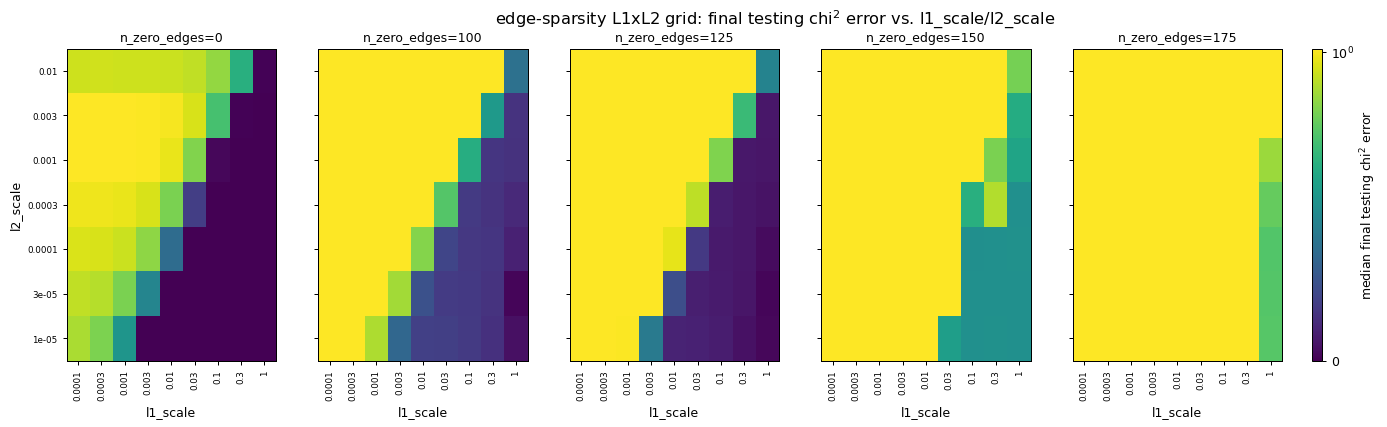

In [ ]:
with tp.teed(
    make_l1l2_heatmap_grid,
    df,
    n_zero_values,
    l1_values,
    l2_values,
    "test_chi2",
    "testing chi$^2$ error",
    "chi2",
    teeplot_outattrs={"dataset": "edge-sparsity-grid", "metric": "test"},
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

## Plot 2: final training (actual) loss heatmap

teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=train+viz=make-l1l2-heatmap-grid+ext=.pdf
teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=train+viz=make-l1l2-heatmap-grid+ext=.png



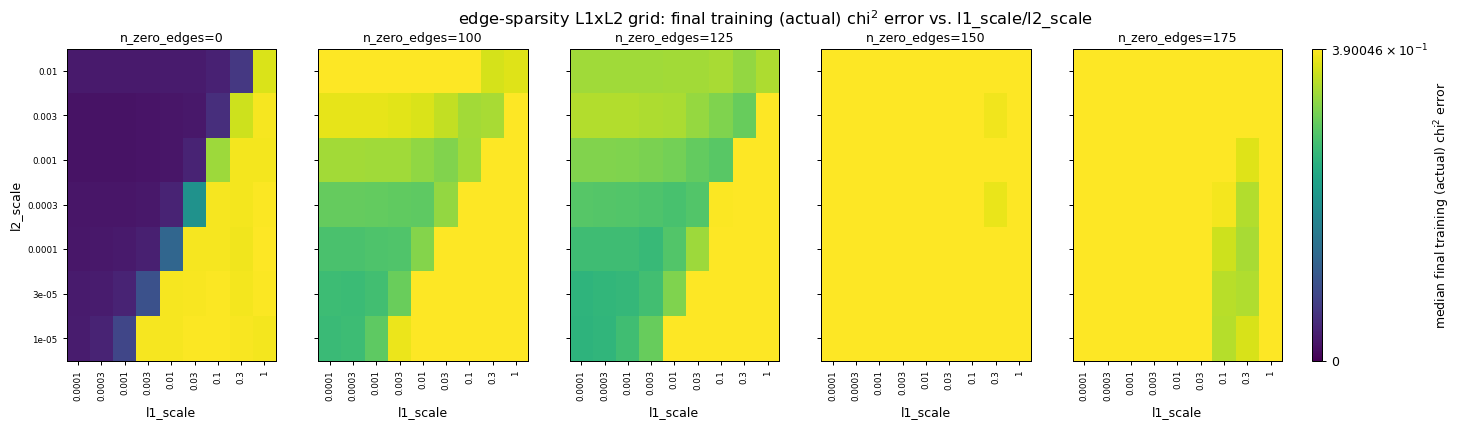

In [ ]:
with tp.teed(
    make_l1l2_heatmap_grid,
    df,
    n_zero_values,
    l1_values,
    l2_values,
    "pure_train_chi2",
    "training (actual) chi$^2$ error",
    "chi2",
    teeplot_outattrs={"dataset": "edge-sparsity-grid", "metric": "train"},
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

## Plot 3: final classified fraction heatmap (1 - other_frac)

teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=classified+viz=make-l1l2-heatmap-grid+ext=.pdf
teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=classified+viz=make-l1l2-heatmap-grid+ext=.png



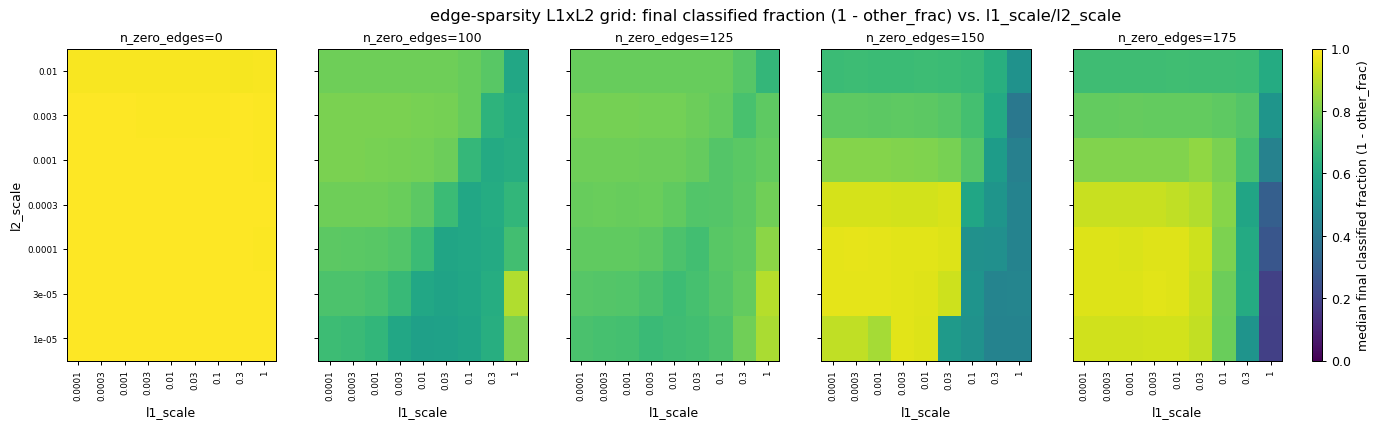

In [ ]:
with tp.teed(
    make_l1l2_heatmap_grid,
    df,
    n_zero_values,
    l1_values,
    l2_values,
    "classified_frac",
    "classified fraction (1 - other_frac)",
    "fraction",
    teeplot_outattrs={
        "dataset": "edge-sparsity-grid",
        "metric": "classified",
    },
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

## Plot 4: phenotype composition facet grid (n_zero_edges x l1_scale x l2_scale)

A facet grid of small stackplots: x-axis = `n_zero_edges` (the same
5 swept values as plots 1-3), column = `l1_scale` (9 values),
row = `l2_scale` (7 values) -- 63 panels total. Each panel stacks
the median (across the 3 replicate seeds) final fraction of each of
the 8 canonical `CLASS_8` phenotypes (`test1_frac`..`test8_frac`)
plus "other" (`other_frac`). `n_classes=3` is fixed dataset-wide
(see "Verify the fixed condition" above), so the train/test-only
split -- and therefore the legend -- is the same in every panel:
classes 1/4/7 (`{S1, S2, S3}`) are drawn at full saturation as
"train", the remaining 5 classes are desaturated/lightened via
`dull()` as "test-only", and "other" is white with a black outline
-- same convention as this project's other composition stackplots
(see `bindle/2026-07-31-exploratory-edge-sparsity-analysis.py`).

In [ ]:
def dull(hex_color, sat_scale=0.35, light_boost=0.25):
    # desaturates + lightens a bright hex color -- used to visually
    # recede "test-only" phenotype classes (never in the training
    # set) behind the full-saturation "train" classes in the same
    # stackplot.
    r, g, b = (int(hex_color[i : i + 2], 16) / 255 for i in (1, 3, 5))
    hue, lightness, sat = colorsys.rgb_to_hls(r, g, b)
    lightness = min(1.0, lightness + light_boost)
    sat = sat * sat_scale
    return colorsys.hls_to_rgb(hue, lightness, sat)

CLASS_COLORS = [
    "#e6194B",
    "#3cb44b",
    "#4363d8",
    "#f58231",
    "#911eb4",
    "#46f0f0",
    "#f032e6",
    "#bcf60c",
]
OTHER_COLOR = "#ffffff"

In [ ]:
def make_composition_facet_grid(df, n_zero_values, l1_values, l2_values):
    FRAC_COLS = [f"test{j}_frac" for j in range(1, 9)]

    final = (
        df.sort_values("generation")
        .groupby(
            ["n_zero_edges", "l1_scale", "l2_scale", "seed"],
            observed=True,
        )
        .tail(1)
    )
    agg = (
        final.groupby(
            ["n_zero_edges", "l1_scale", "l2_scale"], observed=True
        )[FRAC_COLS + ["other_frac"]]
        .median()
        .reset_index()
    )

    train_idx_0based = sorted(
        int(i) for i in df["train_class_idx"].iloc[0].split(",")
    )
    train_idx = [i + 1 for i in train_idx_0based]
    test_only_idx = [i for i in range(1, 9) if i not in train_idx]
    labels = (
        [f"train (test{i})" for i in train_idx]
        + [f"test-only (test{i})" for i in test_only_idx]
        + ["other"]
    )
    colors = (
        [CLASS_COLORS[i - 1] for i in train_idx]
        + [dull(CLASS_COLORS[i - 1]) for i in test_only_idx]
        + [OTHER_COLOR]
    )

    n_rows, n_cols = len(l2_values), len(l1_values)
    fig = plt.figure(figsize=(1.7 * n_cols, 1.4 * n_rows), dpi=90)
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.15, wspace=0.15)

    ax0 = None
    legend_handles = None
    for row, l2s in enumerate(l2_values):
        for col, l1s in enumerate(l1_values):
            if ax0 is None:
                ax = fig.add_subplot(gs[row, col])
                ax0 = ax
            else:
                ax = fig.add_subplot(gs[row, col], sharex=ax0, sharey=ax0)

            cell = (
                agg[(agg["l1_scale"] == l1s) & (agg["l2_scale"] == l2s)]
                .set_index("n_zero_edges")
                .reindex(n_zero_values)
            )
            stack = (
                [cell[f"test{i}_frac"] for i in train_idx]
                + [cell[f"test{i}_frac"] for i in test_only_idx]
                + [cell["other_frac"]]
            )
            polys = ax.stackplot(
                n_zero_values, *stack, colors=colors, labels=labels
            )
            polys[-1].set_edgecolor("black")
            polys[-1].set_linewidth(0.4)
            legend_handles = polys

            ax.set_xlim(min(n_zero_values), max(n_zero_values))
            ax.set_ylim(0, 1)
            ax.set_yticks([0, 0.5, 1])
            ax.tick_params(labelsize=5)
            if row == 0:
                ax.set_title(f"l1={l1s:g}", fontsize=6)
            if col == n_cols - 1:
                ax.yaxis.set_label_position("right")
                ax.set_ylabel(
                    f"l2={l2s:g}",
                    fontsize=6,
                    rotation=0,
                    labelpad=22,
                    va="center",
                )
            if row == n_rows - 1:
                ax.set_xticks(n_zero_values)
                ax.set_xticklabels(
                    [str(v) for v in n_zero_values],
                    rotation=90,
                    fontsize=5,
                )
            else:
                ax.tick_params(labelbottom=False)
            if col != 0:
                ax.tick_params(labelleft=False)

    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.005, 0.5),
        fontsize=8,
        frameon=False,
        handlelength=1.2,
    )
    fig.supxlabel(
        "n_zero_edges (of 256 possible) -- col = l1_scale, "
        "row = l2_scale",
        fontsize=10,
    )
    fig.supylabel("final phenotype fraction", fontsize=10)
    fig.suptitle(
        "edge-sparsity L1xL2 grid: final phenotype composition "
        "facet (x=n_zero_edges, col=l1_scale, row=l2_scale)",
        fontsize=13,
    )
    return fig

teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+viz=composition-facet+ext=.pdf
teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+viz=composition-facet+ext=.png



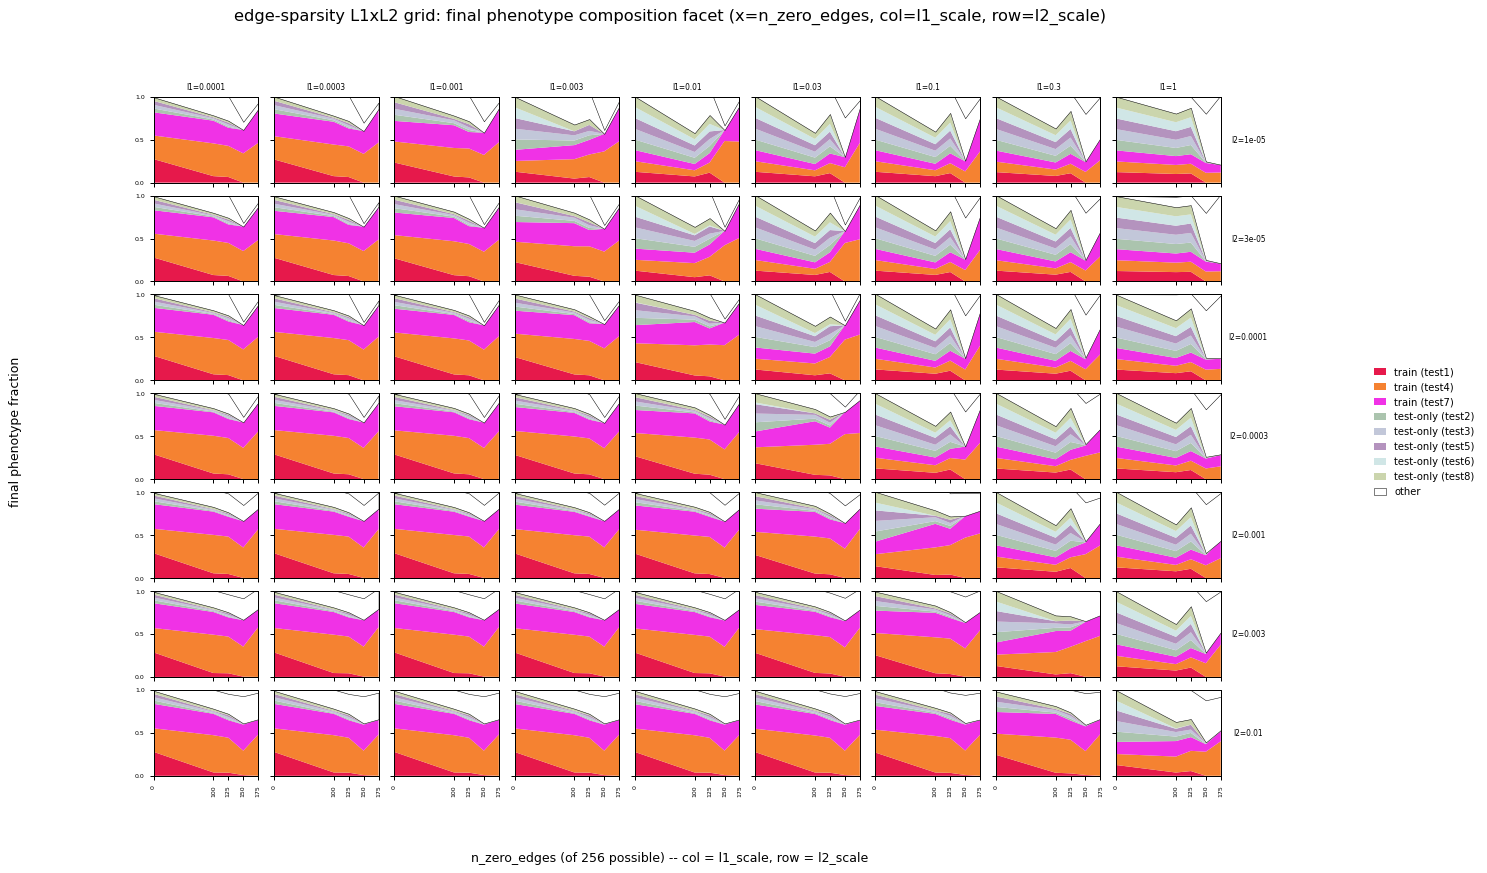

In [ ]:
with tp.teed(
    make_composition_facet_grid,
    df,
    n_zero_values,
    l1_values,
    l2_values,
    teeplot_outattrs={
        "dataset": "edge-sparsity-grid",
        "viz": "composition-facet",
    },
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

## Plots 5 & 6: testing / training chi^2 error facet grid (n_zero_edges x l1_scale x l2_scale)

Same 63-panel facet layout as plot 4 above (column = `l1_scale`,
row = `l2_scale`, x-axis = `n_zero_edges`), but each panel shows the
chi^2 error's median line (across the 3 replicate seeds) with a
shaded [min, max] band, rather than phenotype composition --
`line_color` deliberately contrasts with `band_color` (same
convention as `bindle/2026-07-31-exploratory-edge-sparsity-analysis.py`'s
final loss plot) so the median line stays legible against its own
band. Y-axis is symlog (linear below chi^2=1, log above), shared
across all 63 panels in each figure.

In [ ]:
def _use_readable_symlog_ticks(axis):
    axis.set_major_locator(MaxNLocator(nbins=4))
    axis.set_major_formatter(ScalarFormatter())

def make_chi2_facet_grid(
    df,
    n_zero_values,
    l1_values,
    l2_values,
    metric_col,
    metric_label,
    line_color,
    band_color,
):
    CHI2_LINTHRESH = 1.0

    final = (
        df.sort_values("generation")
        .groupby(
            ["n_zero_edges", "l1_scale", "l2_scale", "seed"],
            observed=True,
        )
        .tail(1)
    )
    agg = (
        final.groupby(
            ["n_zero_edges", "l1_scale", "l2_scale"], observed=True
        )[metric_col]
        .agg(["median", "min", "max"])
        .reset_index()
    )

    n_rows, n_cols = len(l2_values), len(l1_values)
    fig = plt.figure(figsize=(1.7 * n_cols, 1.4 * n_rows), dpi=90)
    gs = GridSpec(n_rows, n_cols, figure=fig, hspace=0.15, wspace=0.15)

    ax0 = None
    for row, l2s in enumerate(l2_values):
        for col, l1s in enumerate(l1_values):
            if ax0 is None:
                ax = fig.add_subplot(gs[row, col])
                ax0 = ax
            else:
                ax = fig.add_subplot(gs[row, col], sharex=ax0, sharey=ax0)

            cell = (
                agg[(agg["l1_scale"] == l1s) & (agg["l2_scale"] == l2s)]
                .set_index("n_zero_edges")
                .reindex(n_zero_values)
            )
            ax.fill_between(
                n_zero_values,
                cell["min"],
                cell["max"],
                color=band_color,
                alpha=0.3,
                lw=0,
            )
            ax.plot(
                n_zero_values,
                cell["median"],
                color=line_color,
                lw=1.2,
            )

            ax.set_yscale("symlog", linthresh=CHI2_LINTHRESH)
            ax.set_ylim(bottom=0)
            _use_readable_symlog_ticks(ax.yaxis)
            ax.set_xlim(min(n_zero_values), max(n_zero_values))
            ax.tick_params(labelsize=5)
            if row == 0:
                ax.set_title(f"l1={l1s:g}", fontsize=6)
            if col == n_cols - 1:
                ax.yaxis.set_label_position("right")
                ax.set_ylabel(
                    f"l2={l2s:g}",
                    fontsize=6,
                    rotation=0,
                    labelpad=22,
                    va="center",
                )
            if row == n_rows - 1:
                ax.set_xticks(n_zero_values)
                ax.set_xticklabels(
                    [str(v) for v in n_zero_values],
                    rotation=90,
                    fontsize=5,
                )
            else:
                ax.tick_params(labelbottom=False)
            if col != 0:
                ax.tick_params(labelleft=False)

    legend_handles = [
        Line2D([0], [0], color=line_color, lw=1.2, label="median"),
        Patch(facecolor=band_color, alpha=0.3, label="[min, max] band"),
    ]
    fig.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(1.005, 0.5),
        fontsize=8,
        frameon=False,
    )
    fig.supxlabel(
        "n_zero_edges (of 256 possible) -- col = l1_scale, "
        "row = l2_scale",
        fontsize=10,
    )
    fig.supylabel(f"{metric_label} chi$^2$ error", fontsize=10)
    fig.suptitle(
        f"edge-sparsity L1xL2 grid: final {metric_label} chi$^2$ "
        "error facet (x=n_zero_edges, col=l1_scale, row=l2_scale)",
        fontsize=13,
    )
    return fig

teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=test+viz=chi2-facet+ext=.pdf
teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=test+viz=chi2-facet+ext=.png



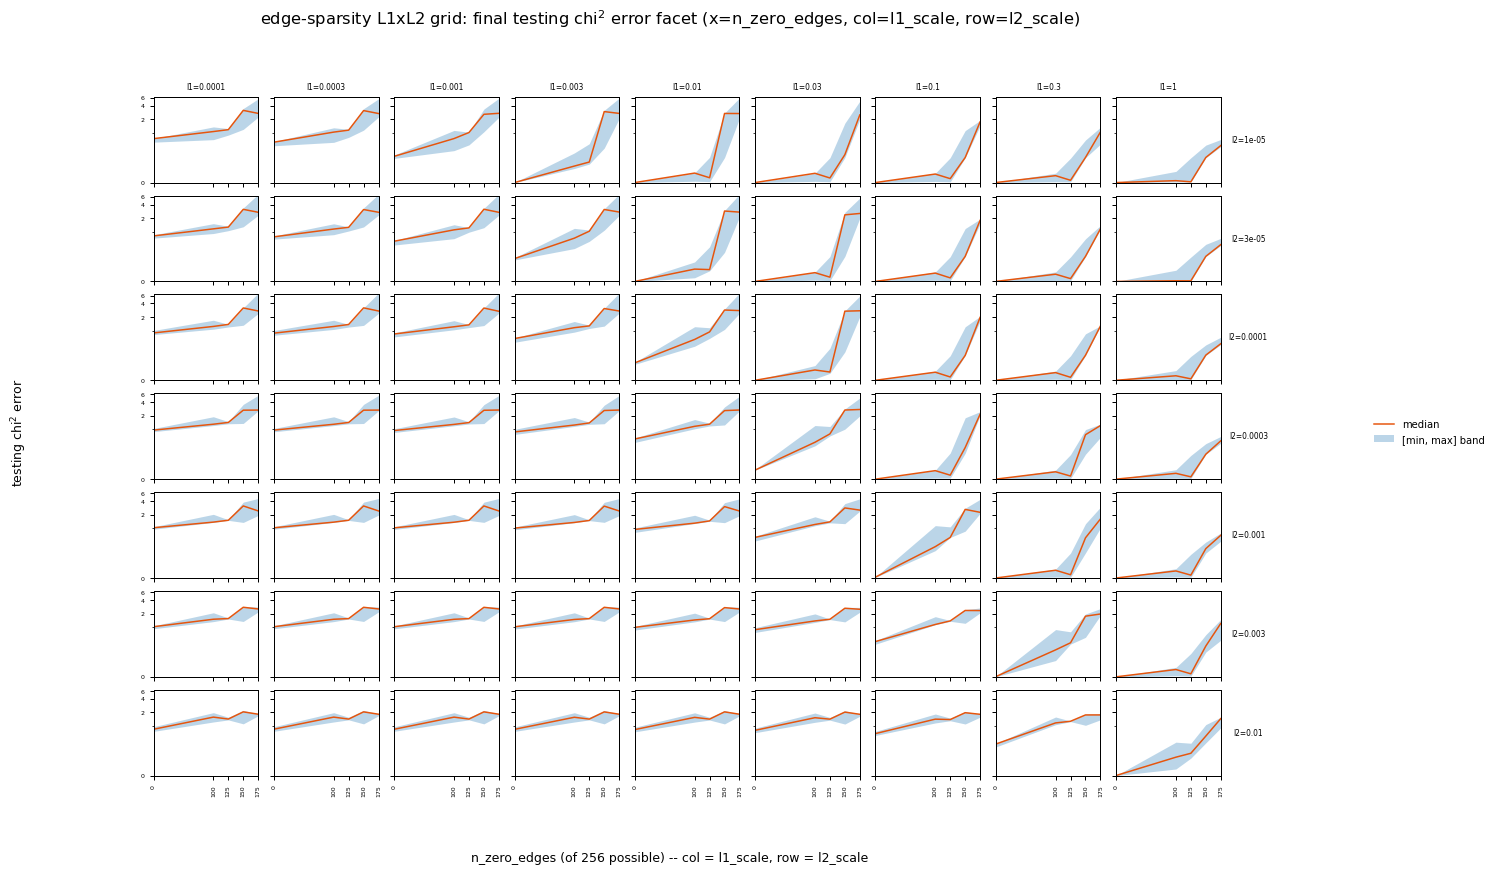

In [ ]:
with tp.teed(
    make_chi2_facet_grid,
    df,
    n_zero_values,
    l1_values,
    l2_values,
    "test_chi2",
    "testing",
    "#e6550d",
    "#1f77b4",
    teeplot_outattrs={
        "dataset": "edge-sparsity-grid",
        "viz": "chi2-facet",
        "metric": "test",
    },
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)

teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=train+viz=chi2-facet+ext=.pdf
teeplots/2026-08-01-edge-sparsity-grid-analysis/dataset=edge-sparsity-grid+metric=train+viz=chi2-facet+ext=.png



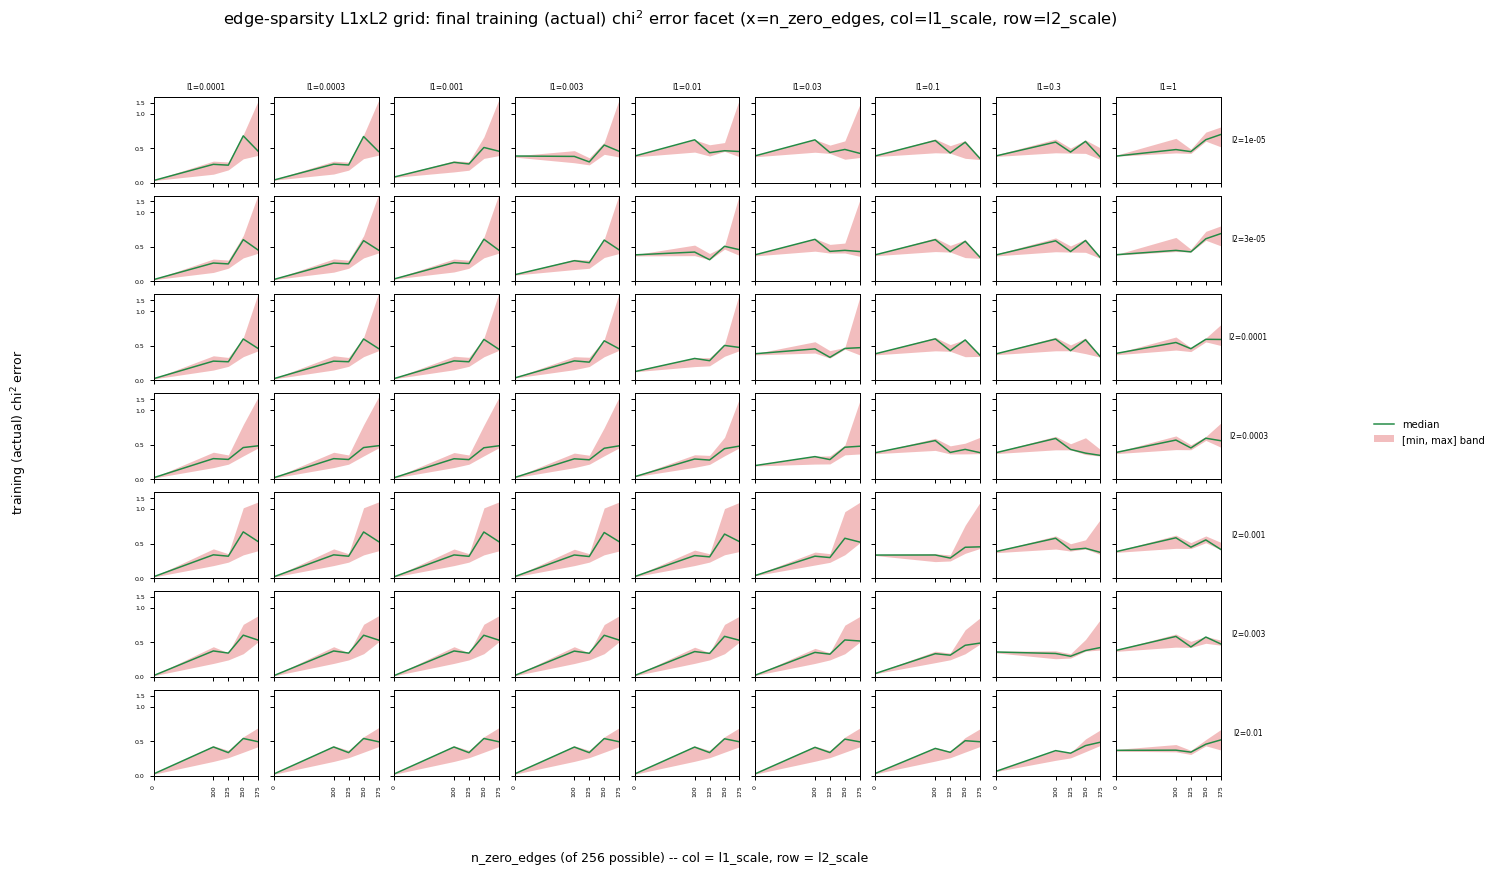

In [ ]:
with tp.teed(
    make_chi2_facet_grid,
    df,
    n_zero_values,
    l1_values,
    l2_values,
    "pure_train_chi2",
    "training (actual)",
    "#238b45",
    "#d62728",
    teeplot_outattrs={
        "dataset": "edge-sparsity-grid",
        "viz": "chi2-facet",
        "metric": "train",
    },
    teeplot_subdir=pathlib.Path(__file__).stem,
    teeplot_show=False,
) as _fig:
    pass
mo.output.append(_fig)
plt.close(_fig)